# 04_06 Regression - LinearRegression with CrossValidator

Train and evaluate LinearRegression using k-fold CrossValidator (3-fold) for hyperparameter tuning.

**Note:** This notebook uses CrossValidator (k-fold CV) instead of TrainValidationSplit, satisfying UTIL-04 requirement.

## [COMMAND_SO]
Command 1

[COMMAND_MUC_DICH]
- Muc tieu nghiep vu: Train LinearRegression voi CrossValidator (3-fold) cho regression task.
- Muc tieu ky thuat: Su dung RegressionEvaluator voi metric='r2', so sanh CV vs TVS.

In [1]:
from pathlib import Path
import json
from pyspark.sql import SparkSession
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import time

# Spark session setup
spark = (SparkSession.builder
    .appName('04_06_lr_cv') # type: ignore
    .master('local[2]')
    .config('spark.sql.shuffle.partitions','16')
    .getOrCreate())
spark.sparkContext.setLogLevel('WARN')

# Paths
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
FEATURE_DIR = PROJECT_ROOT / 'data' / 'processed' / 'features'
MODEL_DIR = PROJECT_ROOT / 'models' / 'regression' / 'linear_regression_cv_best'
METRIC_DIR = PROJECT_ROOT / 'reports' / 'model_metrics'
CROSSVAL_DIR = METRIC_DIR / 'crossvalidator'

MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRIC_DIR.mkdir(parents=True, exist_ok=True)
CROSSVAL_DIR.mkdir(parents=True, exist_ok=True)

# Load regression data (different from classification)
train_df = spark.read.parquet(str(FEATURE_DIR / 'regression_train')).select('order_id','label','features').dropna()
val_df = spark.read.parquet(str(FEATURE_DIR / 'regression_val')).select('order_id','label','features').dropna()
test_df = spark.read.parquet(str(FEATURE_DIR / 'regression_test')).select('order_id','label','features').dropna()

print(f"Train rows: {train_df.count()}, Val rows: {val_df.count()}, Test rows: {test_df.count()}")

26/03/31 23:05:12 WARN Utils: Your hostname, Genius-Macbook.local resolves to a loopback address: 127.0.0.1; using 192.168.2.18 instead (on interface en0)
26/03/31 23:05:12 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/31 23:05:13 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/31 23:05:13 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/03/31 23:05:13 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


Train rows: 69077, Val rows: 14728, Test rows: 14861


## Setup CrossValidator with ParamGrid

**CrossValidator Configuration:**
- numFolds=3 (k-fold cross-validation)
- Grid: regParam=[0.01, 0.1, 1.0], maxIter=[10, 50, 100]
- Metric: R² (R-squared) for CV optimization (per locked decision)
- parallelism=2 (LinearRegression can run parallel)

In [2]:
# Define model
lr = LinearRegression(featuresCol='features', labelCol='label', elasticNetParam=0.0)

# Build param grid (3x3 = 9 combinations)
param_grid = (
    ParamGridBuilder()
    .addGrid(lr.regParam, [0.01, 0.1, 1.0])
    .addGrid(lr.maxIter, [10, 50, 100])
    .build()
)

print(f"Total param combinations: {len(param_grid)}")

# Evaluator for CV - using R² (per locked decision for regression)
cv_evaluator = RegressionEvaluator(
    labelCol='label',
    predictionCol='prediction',
    metricName='r2'  # KEY: R-squared for regression CV optimization
)

# CrossValidator setup
cv = CrossValidator(
    estimator=lr,
    estimatorParamMaps=param_grid,
    evaluator=cv_evaluator,
    numFolds=3,  # KEY: 3-fold cross-validation
    seed=42,
    parallelism=2  # Can run parallel
)

print("CrossValidator configured:")
print(f"  - numFolds: 3")
print(f"  - parallelism: 2")
print(f"  - metric: r2 (R-squared)")
print(f"  - param combinations: {len(param_grid)}")
print(f"  - total models trained: {len(param_grid) * 3}")

Total param combinations: 9
CrossValidator configured:
  - numFolds: 3
  - parallelism: 2
  - metric: r2 (R-squared)
  - param combinations: 9
  - total models trained: 27


## Run CrossValidator

This will train 27 models (9 param combos x 3 folds) and select the best.

In [3]:
# Fit CrossValidator
start_time = time.time()
print("Training CrossValidator (3-fold) for LinearRegression...")

cv_model = cv.fit(train_df)

training_time = time.time() - start_time
print(f"Training completed in {training_time:.2f} seconds")

# Get best model
best_model = cv_model.bestModel
best_regParam = best_model.getRegParam() # type: ignore
best_maxIter = best_model.getMaxIter() # type: ignore

print(f"\nBest params found:")
print(f"  regParam: {best_regParam}")
print(f"  maxIter: {best_maxIter}")

Training CrossValidator (3-fold) for LinearRegression...


26/03/31 23:05:19 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/03/31 23:05:19 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
26/03/31 23:05:19 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


Training completed in 5.86 seconds

Best params found:
  regParam: 1.0
  maxIter: 10


## Display All Param Combinations with CV Scores

In [4]:
# Extract param combinations and their avg CV scores
param_combos = []
for i, params in enumerate(param_grid):
    reg = params[lr.regParam]
    max_iter = params[lr.maxIter]
    avg_score = cv_model.avgMetrics[i]
    param_combos.append({
        'regParam': reg,
        'maxIter': max_iter,
        'cv_avg_r2': float(avg_score)
    })

cv_results_df = pd.DataFrame(param_combos)
cv_results_df = cv_results_df.sort_values('cv_avg_r2', ascending=False)

print("All parameter combinations with CV R² scores (sorted):")
display(cv_results_df)

# Save detailed CV results
cv_results_df.to_csv(CROSSVAL_DIR / 'cv_linear_regression.csv', index=False)
print(f"\nSaved to: {CROSSVAL_DIR / 'cv_linear_regression.csv'}")

All parameter combinations with CV R² scores (sorted):


,regParam,maxIter,cv_avg_r2
6,1.00,10,0.117764
7,1.00,50,0.117764
8,1.00,100,0.117764
3,0.10,10,0.117755
4,0.10,50,0.117755
5,0.10,100,0.117755
0,0.01,10,0.117754
1,0.01,50,0.117754
2,0.01,100,0.117754



Saved to: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/reports/model_metrics/crossvalidator/cv_linear_regression.csv


## Evaluate Best Model on Validation and Test Sets

In [5]:
# Evaluate best model
pred_val = best_model.transform(val_df)
pred_test = best_model.transform(test_df)

# Metrics - all regression metrics
val_rmse = RegressionEvaluator(labelCol='label', predictionCol='prediction', metricName='rmse').evaluate(pred_val)
val_mae = RegressionEvaluator(labelCol='label', predictionCol='prediction', metricName='mae').evaluate(pred_val)
val_r2 = RegressionEvaluator(labelCol='label', predictionCol='prediction', metricName='r2').evaluate(pred_val)
test_rmse = RegressionEvaluator(labelCol='label', predictionCol='prediction', metricName='rmse').evaluate(pred_test)
test_mae = RegressionEvaluator(labelCol='label', predictionCol='prediction', metricName='mae').evaluate(pred_test)
test_r2 = RegressionEvaluator(labelCol='label', predictionCol='prediction', metricName='r2').evaluate(pred_test)

# CV average R² for best params
best_cv_avg = max(cv_model.avgMetrics)

metrics = {
    'model_family': 'regression',
    'model_name': 'LinearRegression_CV',
    'tuning_method': 'CrossValidator',
    'num_folds': 3,
    'best_regParam': float(best_regParam),
    'best_maxIter': int(best_maxIter),
    'cv_avg_r2': float(best_cv_avg),
    'val_rmse': float(val_rmse),
    'val_mae': float(val_mae),
    'val_r2': float(val_r2),
    'test_rmse': float(test_rmse),
    'test_mae': float(test_mae),
    'test_r2': float(test_r2),
    'train_rows': train_df.count(),
    'val_rows': val_df.count(),
    'test_rows': test_df.count(),
    'training_time_seconds': float(training_time),
    'total_combinations': len(param_grid)
}

print("\nFinal Metrics:")
print(metrics)
display(pd.DataFrame([metrics]))


Final Metrics:
{'model_family': 'regression', 'model_name': 'LinearRegression_CV', 'tuning_method': 'CrossValidator', 'num_folds': 3, 'best_regParam': 1.0, 'best_maxIter': 10, 'cv_avg_r2': 0.11776384973190986, 'val_rmse': 203.19351109901442, 'val_mae': 94.13805238254618, 'val_r2': 0.12483743517255175, 'test_rmse': 222.4477441682368, 'test_mae': 94.42154471566349, 'test_r2': 0.10833839602724804, 'train_rows': 69077, 'val_rows': 14728, 'test_rows': 14861, 'training_time_seconds': 5.860810995101929, 'total_combinations': 9}


,model_family,model_name,tuning_method,num_folds,best_regParam,best_maxIter,cv_avg_r2,val_rmse,val_mae,val_r2,test_rmse,test_mae,test_r2,train_rows,val_rows,test_rows,training_time_seconds,total_combinations
0,regression,LinearRegression_CV,CrossValidator,3,1.0,10,0.117764,203.193511,94.138052,0.124837,222.447744,94.421545,0.108338,69077,14728,14861,5.860811,9


## Actual vs Predicted Scatter Plot

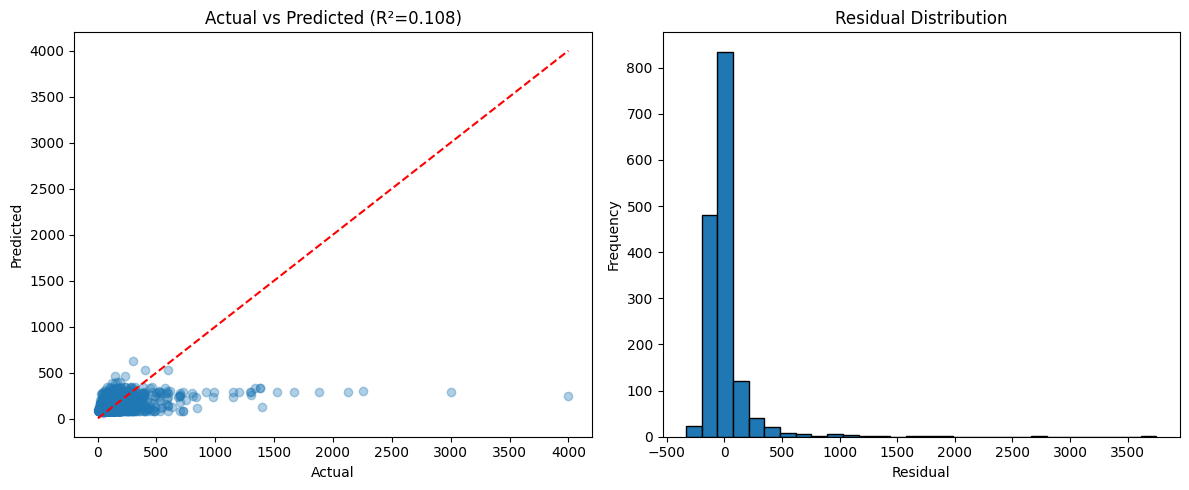

In [6]:
# Sample and plot
sample_pdf = pred_test.select('label','prediction').sample(False, 0.1, 42).toPandas()
if not sample_pdf.empty:
    sample_pdf['residual'] = sample_pdf['label'] - sample_pdf['prediction']

    fig, axes = plt.subplots(1, 2, figsize=(12,5))

    # Scatter plot
    axes[0].scatter(sample_pdf['label'], sample_pdf['prediction'], alpha=0.35)
    axes[0].plot([sample_pdf['label'].min(), sample_pdf['label'].max()],
                [sample_pdf['label'].min(), sample_pdf['label'].max()], 'r--')
    axes[0].set_xlabel('Actual')
    axes[0].set_ylabel('Predicted')
    axes[0].set_title(f'Actual vs Predicted (R²={test_r2:.3f})')

    # Residual histogram
    axes[1].hist(sample_pdf['residual'], bins=30, edgecolor='black')
    axes[1].set_xlabel('Residual')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Residual Distribution')

    plt.tight_layout()
    plt.show()

## CrossValidator vs TrainValidationSplit Comparison

In [7]:
# Load TVS results
tvs_path = METRIC_DIR / 'tuning_regression_linear_regression.json'
tvs_metrics = {}
if tvs_path.exists():
    with open(tvs_path) as f:
        tvs_data = json.load(f)
    # Load main metrics
    tvs_main_path = METRIC_DIR / 'regression_linear_regression.json'
    if tvs_main_path.exists():
        with open(tvs_main_path) as f:
            tvs_main = json.load(f)
        tvs_metrics = {
            'tvs_val_r2': tvs_main.get('val_r2', 'N/A'),
            'tvs_test_r2': tvs_main.get('test_r2', 'N/A'),
            'tvs_test_rmse': tvs_main.get('test_rmse', 'N/A'),
            'tvs_best_params': tvs_data.get('bestParams', {})
        }

# Create comparison
comparison = {
    'metric': ['CV/Val R2', 'Test R2', 'Test RMSE', 'Best regParam', 'Best maxIter'],
    'CrossValidator_CV': [
        f"{best_cv_avg:.4f} (avg 3 folds)",
        f"{test_r2:.4f}",
        f"{test_rmse:.2f}",
        f"{best_regParam}",
        f"{best_maxIter}"
    ],
    'TrainValidationSplit': [
        f"{tvs_metrics.get('tvs_val_r2', 'N/A')}",
        f"{tvs_metrics.get('tvs_test_r2', 'N/A')}",
        f"{tvs_metrics.get('tvs_test_rmse', 'N/A')}",
        f"{tvs_metrics.get('tvs_best_params', {}).get('regParam', 'N/A')}",
        f"{tvs_metrics.get('tvs_best_params', {}).get('maxIter', 'N/A')}"
    ]
}

comparison_df = pd.DataFrame(comparison)
print("CrossValidator vs TrainValidationSplit Comparison:")
display(comparison_df)

# Save comparison
comparison_df.to_csv(CROSSVAL_DIR / 'cv_vs_tvs_linear_regression.csv', index=False)

print(f"\nKey Notes:")
print(f"- CV uses R² metric for optimization (not RMSE)")
print(f"- CV avg R² ({best_cv_avg:.4f}) is average across 3 folds")
print(f"- More stable estimate than single train/val split")

CrossValidator vs TrainValidationSplit Comparison:


,metric,CrossValidator_CV,TrainValidationSplit
0,CV/Val R2,0.1178 (avg 3 folds),0.12493771922191843
1,Test R2,0.1083,0.10844420639467933
2,Test RMSE,222.45,222.43454522832906
3,Best regParam,1.0,0.01
4,Best maxIter,10,80



Key Notes:
- CV uses R² metric for optimization (not RMSE)
- CV avg R² (0.1178) is average across 3 folds
- More stable estimate than single train/val split


## Save Model and Metrics

In [8]:
# Save best model
best_model.write().overwrite().save(str(MODEL_DIR))
print(f"Best model saved to: {MODEL_DIR}")

# Save metrics
metrics_path = METRIC_DIR / 'regression_linear_regression_cv.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f"Metrics saved to: {metrics_path}")

# Save tuning report
tuning_report = {
    'model_family': 'regression',
    'model_name': 'LinearRegression',
    'tuning_method': 'CrossValidator',
    'num_folds': 3,
    'metric': 'r2',
    'avgMetrics': [float(x) for x in cv_model.avgMetrics],
    'bestParams': {
        'regParam': float(best_regParam),
        'maxIter': int(best_maxIter)
    },
    'note': 'Regression uses R2 metric for CV optimization'
}

tuning_path = METRIC_DIR / 'tuning_regression_linear_regression_cv.json'
with open(tuning_path, 'w') as f:
    json.dump(tuning_report, f, indent=2)
print(f"Tuning report saved to: {tuning_path}")

print("\n✅ CrossValidator training complete!")

Best model saved to: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/models/regression/linear_regression_cv_best
Metrics saved to: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/reports/model_metrics/regression_linear_regression_cv.json
Tuning report saved to: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/reports/model_metrics/tuning_regression_linear_regression_cv.json

✅ CrossValidator training complete!
